# Wczytanie zbioru danych i wyekstraktowanie sportowców z USA

In [87]:
# Zaimportowanie biblioteki pandas
import pandas as pd

# Stworzenie zmiennej igrzyska, która wczytuje dane z pliku athlete_events.csv
igrzyska = pd.read_csv('athlete_events.csv')

print(igrzyska)
# Stworzenie zmiennej usa_igrzyska, która pobiera ze zbioru igrzyska rekordy z wartością United States w kolumnie Team, nie pobiera rekordów z brakami danych
usa_igrzyska = igrzyska[igrzyska['Team'].str.contains("United States", na=False)]

# Zapisanie danych z usa_igrzyska do pliku csv, zapisujemy dane bez indeksów rekordów
usa_igrzyska.to_csv('usa.csv', index=False)

            ID                      Name Sex   Age  Height  Weight  \
0            1                 A Dijiang   M  24.0   180.0    80.0   
1            2                  A Lamusi   M  23.0   170.0    60.0   
2            3       Gunnar Nielsen Aaby   M  24.0     NaN     NaN   
3            4      Edgar Lindenau Aabye   M  34.0     NaN     NaN   
4            5  Christine Jacoba Aaftink   F  21.0   185.0    82.0   
...        ...                       ...  ..   ...     ...     ...   
271111  135569                Andrzej ya   M  29.0   179.0    89.0   
271112  135570                  Piotr ya   M  27.0   176.0    59.0   
271113  135570                  Piotr ya   M  27.0   176.0    59.0   
271114  135571        Tomasz Ireneusz ya   M  30.0   185.0    96.0   
271115  135571        Tomasz Ireneusz ya   M  34.0   185.0    96.0   

                  Team  NOC        Games  Year  Season            City  \
0                China  CHN  1992 Summer  1992  Summer       Barcelona   
1          

Wyekstraktowanie sportowców z USA, którzy zdobyli medal

In [88]:
# Zaimportowanie biblioteki pandas
import pandas as pd

# Stworzenie zmiennej igrzyska_usa, która wczytuje dane z pliku usa.csv (utworzony w module powyżej)
igrzyska_usa = pd.read_csv('usa.csv')

# Stworzenie zmiennej usa_medals, która pobiera ze zbioru igrzyska_usa rekordy z zawodnikami, którzy zdobyli medal, rekordy z brakami w tej kolumnie zostają usunięte
usa_medals = igrzyska_usa[igrzyska_usa['Medal'].notna()]

# Zapisanie danych z usa_medals do pliku csv, zapisujemy dane bez indeksów rekordów
usa_medals.to_csv('usa_medale.csv', index=False)

Zliczenie zdobytych medali przez sportowców z USA

In [89]:
# Zaimportowanie biblioteki pandas
import pandas as pd

# Stworzenie zmiennej igrzyska_usa_medale, która wczytuje dane z pliku usa_medale.csv (utworzony w module powyżej)
igrzyska_usa_medale = pd.read_csv('usa_medale.csv')

# Stworzenie zmiennej igrzyska_usa_medale, która pobiera ze zbioru igrzyska_usa_medale rekordy, które w kolumnie Year mają wartość 2016
medale_2016 = igrzyska_usa_medale[igrzyska_usa_medale['Year'] == 2016]

# Stworzenie zmiennej liczba_medali_2016, która przechowuje liczbę zdobytych medali (2016, USA)
liczba_medali_2016 = len(medale_2016)

# Stworzenie zmiennej rodzaje_medali_2016, która zlicza liczbę medali każdego rodzaju (2016, USA)
rodzaje_medali_2016 = medale_2016['Medal'].value_counts()

# Wyświetlenie wszystkich wartości
print(f"Medale USA: {liczba_medali_2016}\n")
print(f"Złote: {rodzaje_medali_2016.get('Gold', 0)}")
print(f"Srebrne: {rodzaje_medali_2016.get('Silver', 0)}")
print(f"Brązowe: {rodzaje_medali_2016.get('Bronze', 0)}")

Medale USA: 264

Złote: 139
Srebrne: 54
Brązowe: 71


#Zliczenie braków danych

In [90]:
import pandas as pd
import numpy as np
# Wczytanie danych
df = pd.read_csv('athlete_events.csv')


In [91]:
# Typy danych zmiennych
print("Typy danych kolumn:")
print(df.dtypes)

Typy danych kolumn:
ID                int64
Name             object
Sex              object
Age             float64
Height          float64
Weight          float64
Team             object
NOC              object
Games            object
Year              int64
Season           object
City             object
Sport            object
Event            object
Medal            object
Medal_status     object
BMI             float64
Height[m]       float64
dtype: object


In [92]:
# Liczba unikalnych wartości w kolumnach
print("\nLiczba unikalnych wartości:")
print(df.nunique())


Liczba unikalnych wartości:
ID              135571
Name            134732
Sex                  2
Age                 74
Height              95
Weight             220
Team              1184
NOC                230
Games               51
Year                35
Season               2
City                42
Sport               66
Event              765
Medal                3
Medal_status         4
BMI               3856
Height[m]           95
dtype: int64


In [93]:
# Liczba braków danych w każdej kolumnie
print("\nBraki danych w kolumnach:")
print(df.isna().sum())


Braki danych w kolumnach:
ID                   0
Name                 0
Sex                  0
Age               9474
Height           60171
Weight           62875
Team                 0
NOC                  0
Games                0
Year                 0
Season               0
City                 0
Sport                0
Event                0
Medal           231333
Medal_status         0
BMI              64263
Height[m]        60171
dtype: int64


In [94]:
# Minimalne wartości numeryczne
print("\nMinimalne wartości numeryczne:")
print(df.min(numeric_only=True))


Minimalne wartości numeryczne:
ID              1.000000
Age            10.000000
Height        127.000000
Weight         25.000000
Year         1896.000000
BMI             8.360954
Height[m]       1.270000
dtype: float64


In [95]:
# Maksymalne wartości numeryczne
print("\nMaksymalne wartości numeryczne:")
print(df.max(numeric_only=True))


Maksymalne wartości numeryczne:
ID           135571.00000
Age              97.00000
Height          226.00000
Weight          214.00000
Year           2016.00000
BMI              63.90158
Height[m]         2.26000
dtype: float64


In [96]:
#Liczba duplikatów
duplicates = df.duplicated().sum()
print("\nLiczba duplikatów rekordów:", duplicates)


Liczba duplikatów rekordów: 1385


In [97]:
# Filtr wieku 60-97
age_60_97 = df[(df["Age"] >= 60) & (df["Age"] <= 97)]

# Rozkład dyscyplin
sport_dist_60_97 = age_60_97["Sport"].value_counts(normalize=True) * 100

print("Rozkład sportów (60–97 lat) w %:")
print(sport_dist_60_97.round(2))

# Liczba osób, które były w art competitions
art_count = age_60_97[age_60_97["Sport"].str.contains("Art", case=False, na=False)].shape[0]
total_count = age_60_97.shape[0]

print(f"\nArt competitions: {art_count}/{total_count} "
      f"({round((art_count/total_count)*100,2)}%)")

Rozkład sportów (60–97 lat) w %:
Sport
Art Competitions    77.20
Shooting             8.66
Equestrianism        6.23
Sailing              4.26
Archery              2.89
Fencing              0.46
Roque                0.15
Rowing               0.15
Name: proportion, dtype: float64

Art competitions: 508/658 (77.2%)


In [98]:
# Filtr wieku 10-15
age_10_15 = df[(df["Age"] >= 10) & (df["Age"] <= 15)]

#Procentowy udział dyscyplin
sport_dist_10_15 = age_10_15["Sport"].value_counts(normalize=True) * 100

print("Rozkład sportów (10–15 lat) w %:")
print(sport_dist_10_15.round(2).head(10))

Rozkład sportów (10–15 lat) w %:
Sport
Swimming                     42.71
Gymnastics                   39.05
Figure Skating                3.48
Diving                        2.62
Rowing                        1.92
Alpine Skiing                 1.80
Athletics                     1.80
Rhythmic Gymnastics           1.43
Speed Skating                 1.13
Short Track Speed Skating     0.52
Name: proportion, dtype: float64


In [99]:
# Filtr wzrostu 200–226
height_200_226 = df[(df["Height"] >= 200) & (df["Height"] <= 226)]

#Procentowy udział dyscyplin
sport_dist_200_226 = height_200_226["Sport"].value_counts(normalize=True) * 100

print("Rozkład sportów (200–226 cm) w %:")
print(sport_dist_200_226.round(2).head(10))

Rozkład sportów (200–226 cm) w %:
Sport
Basketball          36.27
Volleyball          16.23
Rowing              10.19
Swimming            10.00
Athletics            7.50
Handball             4.96
Water Polo           4.04
Beach Volleyball     1.77
Judo                 1.19
Fencing              0.96
Name: proportion, dtype: float64


In [100]:
# Filtr wzrostu 127–150
height_127_150 = df[(df["Height"] >= 127) & (df["Height"] <= 150)]

#Procentowy udział dyscyplin
sport_dist_127_150 = height_127_150["Sport"].value_counts(normalize=True) * 100

print("Rozkład sportów (127–150 cm) w %:")
print(sport_dist_127_150.round(2).head(10))

Rozkład sportów (127–150 cm) w %:
Sport
Gymnastics        73.17
Weightlifting      5.87
Athletics          3.73
Figure Skating     2.61
Diving             1.96
Swimming           1.77
Wrestling          1.68
Boxing             1.58
Rowing             1.40
Judo               1.35
Name: proportion, dtype: float64


In [101]:
#Filtr wagi 25-50kg
weight_25_50 = df[(df["Weight"] >= 25) & (df["Weight"] <= 50)]

#Procentowy udział dyscyplin
sport_dist_25_50 = weight_25_50["Sport"].value_counts(normalize=True) * 100
print("Rozkład sportów (25–50 kg) w %:")
print(sport_dist_25_50.round(2).head(10))

Rozkład sportów (25–50 kg) w %:
Sport
Gymnastics              44.03
Athletics               16.80
Figure Skating           4.01
Swimming                 3.63
Rhythmic Gymnastics      3.57
Boxing                   3.23
Diving                   2.90
Rowing                   2.60
Wrestling                1.81
Cross Country Skiing     1.72
Name: proportion, dtype: float64


In [102]:
#Filtr wagi 145-214kg
weight_145_214 = df[(df["Weight"] >=145) & (df["Weight"] <= 214)]

#Procentowy udział dyscyplin
sport_dist_145_214 = weight_145_214["Sport"].value_counts(normalize=True) * 100
print("Rozkład sportów (145–214kg) w %:")
print(sport_dist_145_214.round(2).head(10))

Rozkład sportów (145–214kg) w %:
Sport
Weightlifting    54.11
Judo             18.49
Athletics        17.81
Wrestling         8.22
Basketball        0.68
Bobsleigh         0.68
Name: proportion, dtype: float64


In [103]:
# Dodanie kolumny Medal_status - zamiana braków w kolumnie Medal na etykietę No Medal
df["Medal_status"] = df["Medal"].fillna("No Medal")


In [104]:
# Dodanie kolumny Height[m]
df['Height[m]'] = df['Height'] / 100

# Dodanie kolumny BMI
df["BMI"] = np.where(
    (df["Height[m]"].notna()) & (df["Weight"].notna()),
    df["Weight"] / (df["Height[m]"]**2),
    np.nan
)


df.to_csv('athlete_events.csv', index=False)

# Wykresy boxplot


Dane wczytane pomyślnie.


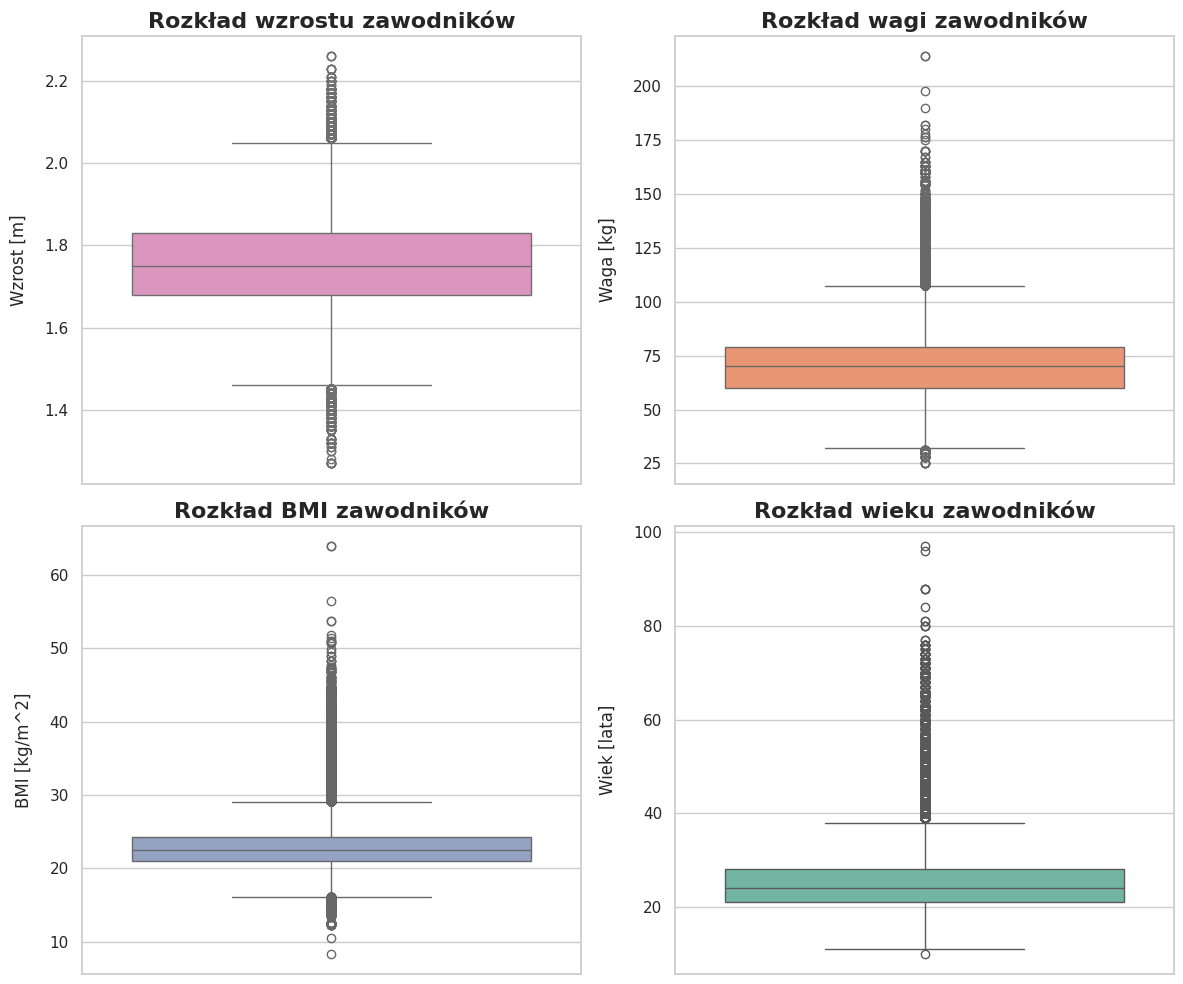

In [105]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Wczytanie danych
try:
    df = pd.read_csv('athlete_events.csv')
    print("Dane wczytane pomyślnie.")
except FileNotFoundError:
    print("Błąd: Nie znaleziono pliku athlete_events.csv.")
    exit()

# Zmiany wizualne wykresów
title_style = {
    'fontsize': 16,
    'fontweight': 'bold'
}

label_style = {
    'labelpad': 12
}

# Ustawienia stylu i kolorów
sns.set_theme(style="whitegrid")
colors = sns.color_palette("Set2")

# Tworzenie siatki 2 wiersze i 2 kolumny
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Wykres I - Rozkład wzrostu zawodników
sns.boxplot(data=df, y='Height[m]', color=colors[3], ax=axes[0, 0])
axes[0, 0].set_title('Rozkład wzrostu zawodników', **title_style)
axes[0, 0].set_ylabel('Wzrost [m]', **label_style)

# Wykres II - Rozkład wagi zawodników
sns.boxplot(data=df, y='Weight', color=colors[1], ax=axes[0, 1])
axes[0, 1].set_title('Rozkład wagi zawodników', **title_style)
axes[0, 1].set_ylabel('Waga [kg]', **label_style)

# Wykres III - Rozkład BMI zawodników
sns.boxplot(data=df, y='BMI', color=colors[2], ax=axes[1, 0])
axes[1, 0].set_title('Rozkład BMI zawodników', **title_style)
axes[1, 0].set_ylabel('BMI [kg/m^2]', **label_style)

# Wykres IV - Rozkład wieku zawodników
sns.boxplot(data=df, y='Age', color=colors[0], ax=axes[1, 1])
axes[1, 1].set_title('Rozkład wieku zawodników', **title_style)
axes[1, 1].set_ylabel('Wiek [lata]', **label_style)

# Zapisanie wykresów do pliku
plt.tight_layout()
plt.savefig('boxplot.png', dpi=300)
plt.show()

#Parametryczna analiza (statystyki opisowe)

In [106]:
# Statystyki opisowe (parametryczne)
desc_stats = df[["Age", "Height", "Weight", "BMI"]].describe()
print(desc_stats)
desc_stats.to_csv("statystyki_opisowe.csv")

                 Age         Height         Weight            BMI
count  261642.000000  210945.000000  208241.000000  206853.000000
mean       25.556898     175.338970      70.702393      22.784520
std         6.393561      10.518462      14.348020       2.912067
min        10.000000     127.000000      25.000000       8.360954
25%        21.000000     168.000000      60.000000      20.957171
50%        24.000000     175.000000      70.000000      22.530864
75%        28.000000     183.000000      79.000000      24.212293
max        97.000000     226.000000     214.000000      63.901580


#Analiza tabelaryczna

In [107]:
#Struktura płci
sex_table = df["Sex"].value_counts()
sex_table.to_csv("tabela_plec.csv")
print(sex_table)

Sex
M    196594
F     74522
Name: count, dtype: int64


In [108]:
#Struktura zdobytych medali
medal_table = df["Medal"].value_counts()
medal_table.to_csv("tabela_medale.csv")
print(medal_table)

Medal
Gold      13372
Bronze    13295
Silver    13116
Name: count, dtype: int64


In [109]:
#Top sporty
sport_table = df["Sport"].value_counts().head(15)
sport_table.to_csv("tabela_top_sporty.csv")
print(sport_table)

Sport
Athletics               38624
Gymnastics              26707
Swimming                23195
Shooting                11448
Cycling                 10859
Fencing                 10735
Rowing                  10595
Cross Country Skiing     9133
Alpine Skiing            8829
Wrestling                7154
Football                 6745
Sailing                  6586
Equestrianism            6344
Canoeing                 6171
Boxing                   6047
Name: count, dtype: int64


#Współzależności między zmiennymi

In [110]:
#Korelacje cech fizycznych
corr_matrix = df[["Age", "Height", "Weight", "BMI"]].corr()
print(corr_matrix)

corr_matrix.to_csv("macierz_korelacji.csv")

             Age    Height    Weight       BMI
Age     1.000000  0.138246  0.212069  0.218230
Height  0.138246  1.000000  0.796213  0.335855
Weight  0.212069  0.796213  1.000000  0.830461
BMI     0.218230  0.335855  0.830461  1.000000


In [111]:
#Wykres korelacji
plt.figure(figsize=(8,6))

#Stworzenie etykiet w języku polskim
etykiety = ['Wiek', 'Wzrost', 'Waga', 'BMI']

sns.heatmap(corr_matrix, annot=True, cmap="BrBG", center=0,
            xticklabels=etykiety,
            yticklabels=etykiety)
plt.title("Macierz korelacji cech fizycznych",
          fontsize=16,
          fontweight='bold')
plt.gca().invert_yaxis()
plt.savefig("korelacje.png", dpi=300)
plt.close()





#Współzależności strukturalne

In [112]:
#BMI vs sport
bmi_by_sport = df.groupby("Sport")["BMI"].mean().sort_values(ascending=False)
bmi_by_sport.head(10).to_csv("bmi_top_sporty.csv")

In [113]:

#BMI vs medal
bmi_medal = df.groupby(df["Medal"].notna())["BMI"].mean()
print(bmi_medal)

Medal
False    22.719604
True     23.164300
Name: BMI, dtype: float64


In [114]:
#Wiek vs medal
age_medal = df.groupby(df["Medal"].notna())["Age"].mean()
print(age_medal)

Medal
False    25.492289
True     25.925175
Name: Age, dtype: float64


#Analiza danych nietypowych

In [115]:
# Analiza outlierów statystycznych (IQR)
def detect_outliers_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return lower, upper

outlier_info = {}

for col in ["Age", "Height", "Weight", "BMI"]:
    data = df[col].dropna()
    low, high = detect_outliers_iqr(data)
    outliers = df[(df[col] < low) | (df[col] > high)]

    outlier_info[col] = {
        "low": low,
        "high": high,
        "count": len(outliers)
    }

    print(f"\n{col}:")
    print(f"Zakres IQR: {round(low,2)} – {round(high,2)}")
    print(f"Liczba outlierów: {len(outliers)}")


Age:
Zakres IQR: 10.5 – 38.5
Liczba outlierów: 10317

Height:
Zakres IQR: 145.5 – 205.5
Liczba outlierów: 1338

Weight:
Zakres IQR: 31.5 – 107.5
Liczba outlierów: 3237

BMI:
Zakres IQR: 16.07 – 29.09
Liczba outlierów: 6276


In [116]:
#Z-score
from scipy.stats import zscore

z_scores = df[["Age","Height","Weight","BMI"]].dropna().apply(zscore)

z_outliers = (abs(z_scores) > 3).sum()

print("\nLiczba obserwacji o |z-score| > 3:")
print(z_outliers)


Liczba obserwacji o |z-score| > 3:
Age       2619
Height     855
Weight    2113
BMI       2827
dtype: int64


In [117]:
#Anomalie strukturalne - nietypowe kombinacje cech
#Bardzo młody wiek + duża masa ciała
anomaly_1 = df[(df["Age"] < 14) & (df["Weight"] > 80)]
print("Nietypowe kombinacje: młody wiek + wysoka waga:", len(anomaly_1))

#Bardzo niski wzrost + wysoka waga
anomaly_2 = df[(df["Height"] < 150) & (df["Weight"] > 90)]
print("Nietypowe kombinacje: niski wzrost + wysoka waga:", len(anomaly_2))


Nietypowe kombinacje: młody wiek + wysoka waga: 0
Nietypowe kombinacje: niski wzrost + wysoka waga: 0


In [118]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

# wzrost vs waga
plt.figure(figsize=(7,6))
sns.scatterplot(data=df, x="Height", y="Weight", alpha=0.4, color="darkcyan")
plt.title("Wzrost vs Waga",
          fontsize=16,
          fontweight='bold')
plt.xlabel("Wzrost [cm]", labelpad=12)
plt.ylabel("Waga [kg]", labelpad=12)
plt.savefig("anomalie_wzrost_waga.png", dpi=300)
plt.close()

# BMI vs wiek
plt.figure(figsize=(7,6))
sns.scatterplot(data=df, x="Age", y="BMI", alpha=0.4, color="darkcyan")
plt.title("Wiek vs BMI",
          fontsize=16,
          fontweight='bold')
plt.xlabel("Wiek [lata]", labelpad=12)
plt.ylabel("BMI [kg/m^2]", labelpad=12)
plt.savefig("anomalie_wiek_bmi.png", dpi=300)
plt.close()


#Analiza braków danych

In [119]:
#Analiza ilościowa braków danych
missing_counts = df.isna().sum()
missing_percent = (df.isna().mean() * 100).round(2)

missing_table = pd.DataFrame({
    "Braki (liczba)": missing_counts,
    "Braki (%)": missing_percent
})

print(missing_table.sort_values("Braki (%)", ascending=False))

# Zapis do CSV
missing_table.to_csv("braki_danych.csv")

              Braki (liczba)  Braki (%)
Medal                 231333      85.33
BMI                    64263      23.70
Weight                 62875      23.19
Height                 60171      22.19
Height[m]              60171      22.19
Age                     9474       3.49
Name                       0       0.00
ID                         0       0.00
Team                       0       0.00
Sex                        0       0.00
Year                       0       0.00
Games                      0       0.00
NOC                        0       0.00
Season                     0       0.00
Event                      0       0.00
Sport                      0       0.00
City                       0       0.00
Medal_status               0       0.00


In [120]:
#Analiza wzorców braków danych
#Macierz współwystępowania braków
missing_corr = df.isna().corr()

print(missing_corr)

missing_corr.to_csv("korelacje_brakow.csv")

#Wizualizacja wzorców braków danych
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(missing_corr, cmap="BrBG", center=0, annot=True, fmt=".2f", annot_kws={"size": 8})
plt.title("Współwystępowanie braków danych - korelacje braków",
          fontsize=16,
          fontweight='bold')
plt.subplots_adjust(bottom=0.30)
plt.gca().invert_yaxis()
plt.savefig("wzorce_brakow.png", dpi=300)
plt.close()




              ID  Name  Sex       Age    Height    Weight  Team  NOC  Games  \
ID           NaN   NaN  NaN       NaN       NaN       NaN   NaN  NaN    NaN   
Name         NaN   NaN  NaN       NaN       NaN       NaN   NaN  NaN    NaN   
Sex          NaN   NaN  NaN       NaN       NaN       NaN   NaN  NaN    NaN   
Age          NaN   NaN  NaN  1.000000  0.313901  0.305281   NaN  NaN    NaN   
Height       NaN   NaN  NaN  0.313901  1.000000  0.942780   NaN  NaN    NaN   
Weight       NaN   NaN  NaN  0.305281  0.942780  1.000000   NaN  NaN    NaN   
Team         NaN   NaN  NaN       NaN       NaN       NaN   NaN  NaN    NaN   
NOC          NaN   NaN  NaN       NaN       NaN       NaN   NaN  NaN    NaN   
Games        NaN   NaN  NaN       NaN       NaN       NaN   NaN  NaN    NaN   
Year         NaN   NaN  NaN       NaN       NaN       NaN   NaN  NaN    NaN   
Season       NaN   NaN  NaN       NaN       NaN       NaN   NaN  NaN    NaN   
City         NaN   NaN  NaN       NaN       NaN     

In [121]:
#Wzorce logiczne braków
#Braki w Height i Weight razem
hw_missing = df[df["Height"].isna() & df["Weight"].isna()]
print("Braki jednoczesne Height & Weight:", len(hw_missing))
#Braki w Age vs Height/Weight
age_hw_missing = df[df["Age"].isna() & (df["Height"].isna() | df["Weight"].isna())]
print("Braki Age + Height/Weight:", len(age_hw_missing))

Braki jednoczesne Height & Weight: 58783
Braki Age + Height/Weight: 8786


In [122]:
#Analiza strukturalna braków - Czy braki zależą od sportu?
missing_by_sport = df.groupby("Sport")[["Age","Height","Weight"]].apply(lambda x: x.isna().mean()*100)

print(missing_by_sport.sort_values(by="Height", ascending=False).head(10))

missing_by_sport.to_csv("braki_vs_sport.csv")

                           Age      Height      Weight
Sport                                                 
Aeronautics           0.000000  100.000000  100.000000
Alpinism             36.000000  100.000000  100.000000
Roque                25.000000  100.000000  100.000000
Basque Pelota         0.000000  100.000000  100.000000
Cricket              25.000000  100.000000  100.000000
Croquet              21.052632  100.000000  100.000000
Military Ski Patrol  20.833333  100.000000  100.000000
Art Competitions     14.169927   98.351034   98.462828
Lacrosse             40.000000   96.666667   88.333333
Polo                  5.263158   95.789474  100.000000


# Tabela przestawna braków wzrostu i wagi

In [123]:
import pandas as pd

df = pd.read_csv('athlete_events.csv')

#Tworzenie kolumn
df['wzrost'] = df['Height'].isna()
df['waga'] = df['Weight'].isna()

#Tabela przestawna
tabela_brakow = pd.crosstab(df['wzrost'], df['waga'],
                            rownames=['wzrost'],
                            colnames=['waga'])

print(tabela_brakow)

#Obliczanie (%)
razem_brak_wzrostu = tabela_brakow.loc[True, :].sum()
razem_brak_wagi = tabela_brakow.loc[:, True].sum()

brak_obu = tabela_brakow.loc[True, True]

#Obliczanie szansy
szansa_waga_gdy_brak_wzrostu = (brak_obu / razem_brak_wzrostu) * 100
szansa_wzrost_gdy_brak_wagi = (brak_obu / razem_brak_wagi) * 100

print(f"szansa na brak wagi przy braku wzrostu: {szansa_waga_gdy_brak_wzrostu:.2f}%")
print(f"zansa na brak wzrostu przy braku wagi: {szansa_wzrost_gdy_brak_wagi:.2f}%")

waga     False  True 
wzrost               
False   206853   4092
True      1388  58783
szansa na brak wagi przy braku wzrostu: 97.69%
zansa na brak wzrostu przy braku wagi: 93.49%


# Analiza wzrostów olimpijczyków

In [124]:
#Liczba zawodników w danym roku danej płci danego kraju oraz ich średni wzrost
import pandas as pd

df = pd.read_csv('athlete_events.csv')
kraj = 'JPN'
#Filtrowanie danych
sportowcy = df[
    (df['Year'] == 2016) &
    (df['Sex'] == 'M') &
    (df['NOC'] == kraj)
    # & (df['Sport'] != 'Handball') & (df['Sport'] != 'Rowing') & (df['Sport'] != 'Volleyball') & (df['Sport'] != 'Basketball')
]

sredni_wzrost = sportowcy['Height'].mean()

liczba_zawodnikow = sportowcy['ID'].nunique()

print(f"Liczba zawodnikow {kraj}: {liczba_zawodnikow}")
print(f"Średni wzrost: {sredni_wzrost:.2f} cm")


zestawienie = sportowcy.groupby('Sport')['ID'].nunique().sort_values(ascending=False).reset_index()
print("sportowcy " + kraj + " wg dyscyplin:")
print(zestawienie.to_string(index=False))

Liczba zawodnikow JPN: 171
Średni wzrost: 174.63 cm
sportowcy JPN wg dyscyplin:
            Sport  ID
        Athletics  37
         Swimming  18
         Football  17
     Rugby Sevens  12
       Water Polo  12
          Cycling   8
             Judo   7
    Equestrianism   7
       Gymnastics   5
         Shooting   5
          Sailing   5
         Canoeing   4
        Badminton   4
        Wrestling   4
    Weightlifting   3
           Tennis   3
     Table Tennis   3
          Fencing   3
           Rowing   2
           Diving   2
           Boxing   2
             Golf   2
     Trampolining   2
Modern Pentathlon   2
          Archery   1
        Triathlon   1


In [125]:
#Średnie wzrosty wszystkich krajów na świecie 1985-2019 (tylko 19-latkowie)
import pandas as pd

#Wczytanie danych
df = pd.read_csv('heights.csv')

#Filtrowanie rekordów dla wieku 19 lat
df_19 = df[df['Age group'] == 19]

#Zapisanie przefiltrowanych danych do nowego pliku
df_19.to_csv('heights_age_19.csv', index=False)

#Wyświetlenie podglądu
print(df_19.head())

        Country   Sex  Year  Age group  Mean height  \
14  Afghanistan  Boys  1985         19   165.274786   
29  Afghanistan  Boys  1986         19   165.430748   
44  Afghanistan  Boys  1987         19   165.597909   
59  Afghanistan  Boys  1988         19   165.778218   
74  Afghanistan  Boys  1989         19   165.955873   

    Mean height lower 95% uncertainty interval  \
14                                  158.942852   
29                                  159.525060   
44                                  160.007610   
59                                  160.480902   
74                                  160.960459   

    Mean height upper 95% uncertainty interval  Mean height standard error  
14                                  171.691963                    3.237744  
29                                  171.473342                    3.051448  
44                                  171.255144                    2.874716  
59                                  171.109287              

In [126]:
#Tabele z róznicami we wzrostach olimpijczyków i mieszkańców z danych krajów
import pandas as pd

df_atleci = pd.read_csv("athlete_events.csv")
df_populacja = pd.read_csv("heights_age_19.csv")

#Zamiana etykiet w pliku ze wzrostami żeby zgadzały się z plikiem athlete_events
df_pop_2016 = df_populacja[df_populacja['Year'] == 2016].copy()
df_pop_2016['Sex'] = df_pop_2016['Sex'].map({'Boys': 'M', 'Girls': 'F'})

#Obliczanie średniego wzrostu olimpijczyka w 2016
df_atl_2016 = df_atleci[df_atleci['Year'] == 2016]
atl_srednie = df_atl_2016.groupby(['Team', 'Sex'])['Height'].agg(['mean', 'count']).reset_index()
atl_srednie.columns = ['Country', 'Sex', 'Height_Olimp', 'Liczba_Sportowcow']

#Łączenie tabel - nie wszystkie nazwy krajów się zgadzają, ale dla zdecydowanej większosci tak
porownanie = pd.merge(atl_srednie, df_pop_2016[['Country', 'Sex', 'Mean height']],
                      on=['Country', 'Sex'], how='inner')

porownanie['Roznica_cm'] = porownanie['Height_Olimp'] - porownanie['Mean height']

#Zapisujemy te kraje, które mialy co najmniej 3 sportowców
wynik_finalny = porownanie[porownanie['Liczba_Sportowcow'] >= 3].sort_values(by='Roznica_cm', ascending=False)

#Top 10 krajow z najwieksza roznicą:
print("kraje z największą róznicą wsrod mężczyzn:")
print(wynik_finalny[wynik_finalny['Sex'] == 'M'].head(10).to_string(index=False))

print("kraje z największą róznicą wsrod kobiet")
print(wynik_finalny[wynik_finalny['Sex'] == 'F'].head(10).to_string(index=False))

print("kraje z najmniejszą róznicą wsrod mężczyzn:")
print(wynik_finalny[wynik_finalny['Sex'] == 'M'].tail(10).to_string(index=False))

print("kraje z najmniejszą róznicą wsrod kobiet")
print(wynik_finalny[wynik_finalny['Sex'] == 'F'].tail(10).to_string(index=False))

wynik_finalny.to_csv("roznica_wzrostu_populacja_vs_olimp.csv", index=False)

kraje z największą róznicą wsrod mężczyzn:
      Country Sex  Height_Olimp  Liczba_Sportowcow  Mean height  Roznica_cm
Cote d'Ivoire   M    185.500000                  6   167.818671   17.681329
        Niger   M    185.750000                  4   169.899019   15.850981
        Benin   M    183.750000                  4   168.030129   15.719871
   Tajikistan   M    183.400000                  5   168.008605   15.391395
 Burkina Faso   M    185.333333                  3   171.363536   13.969797
 Turkmenistan   M    187.250000                  4   173.794643   13.455357
        Qatar   M    185.275000                 40   172.410925   12.864075
      Albania   M    186.000000                  3   173.593377   12.406623
     Pakistan   M    179.000000                  3   166.655576   12.344424
        Ghana   M    182.000000                  3   170.006295   11.993705
kraje z największą róznicą wsrod kobiet
    Country Sex  Height_Olimp  Liczba_Sportowcow  Mean height  Roznica_cm
    Bur

In [127]:
#Średnio o ile wyższy jest olimpijczyk z danego kraju od średniego mieszkańca tego kraju?

import pandas as pd

#Wczytanie pliku
df = pd.read_csv("roznica_wzrostu_populacja_vs_olimp.csv")

#Obliczenie średniej różnicy dla wszystkich krajów i płci łącznie
srednia_ogolna = df['Roznica_cm'].mean()

#Obliczenie średniej różnicy z podziałem na płeć (ciekawa statystyka)
srednia_plec = df.groupby('Sex')['Roznica_cm'].mean()

#Wyświetlenie wyników
print(f"Srednia różnica (Olimpijczyk vs Obywatel): {srednia_ogolna:.2f} cm")
print("-" * 30)
print(f"Średnia dla mężczyzn (M): {srednia_plec.get('M', 0):.2f} cm")
print(f"Średnia dla kobiet (F): {srednia_plec.get('F', 0):.2f} cm")

#Średnia ważona (biorąca pod uwagę liczbę sportowców)
# To jest bardziej precyzyjne, bo kraje z 1 sportowcem nie ważą tyle samo co USA
srednia_wazona = (df['Roznica_cm'] * df['Liczba_Sportowcow']).sum() / df['Liczba_Sportowcow'].sum()

print(f"Średnia ważona liczbą sportowców: {srednia_wazona:.2f} cm")

Srednia różnica (Olimpijczyk vs Obywatel): 5.95 cm
------------------------------
Średnia dla mężczyzn (M): 5.81 cm
Średnia dla kobiet (F): 6.13 cm
Średnia ważona liczbą sportowców: 5.84 cm


In [128]:
#Liczenie średniej  wzrostu wszystkich sportowców na igrzyskach 1896-2016
import pandas as pd

#Wczytanie danych
df = pd.read_csv("athlete_events.csv")

#Obliczenie średniej dla kolumny Height
srednia_wzrostu = df['Height'].mean()

#Zliczanie ile rekordów było branych pod uwagę
liczba_danych = df['Height'].count()
liczba_brakow = df['Height'].isna().sum()

#Wyświetlenie wyników
print(f"Średni wzrost sportowców: {srednia_wzrostu:.2f} cm")
print(f"Liczba poprawnych rekordów: {liczba_danych}")
print(f"Liczba braków danych: {liczba_brakow}")

Średni wzrost sportowców: 175.34 cm
Liczba poprawnych rekordów: 210945
Liczba braków danych: 60171


# Imputacja wzrostu

In [129]:
import pandas as pd

df = pd.read_csv("athlete_events.csv")
df_pop = pd.read_csv("heights_age_19.csv")

srednie_sporty = df.groupby(['Sport', 'Sex'])['Height'].mean().to_dict()

#Średnia róznica wzrostów olimpijczyka od wzrostu średniego mieszkańca kraju
GLOBAL_OFFSET = 5.95

#Mapowania zespołów które są problematyczne
mapowanie_teamow = {
    "Czechoslovakia": "Czech Republic",
    "Union des Socits Franais de Sports Athletiques": "France",
    "Devon and Somerset Wanderers": "United Kingdom",
    "Quicksilver-2": "United Kingdom",
    "Great Britain": "United Kingdom",
    "United States": "United States of America"
}

def imputuj_wzrost(row):
    if pd.notna(row['Height']):
        return row['Height']

    #Historyczna średnia wzrostu dla sportowców danej kategorii i danej płci
    klucz_sport = (row['Sport'], row['Sex'])
    if klucz_sport in srednie_sporty and pd.notna(srednie_sporty[klucz_sport]):
        return round(srednie_sporty[klucz_sport], 1)

#Średnia wzrostu dla danego kraju w danym roku danej płci + 5,95 cm

    #Sprawdzenie, czy nazwa wymaga poprawki przed szukaniem w pliku
    nazwa_teamu = row['Team']
    if nazwa_teamu in mapowanie_teamow:
        nazwa_teamu = mapowanie_teamow[nazwa_teamu]

    rok_ref = row['Year'] if row['Year'] >= 1985 else 1985
    plec_map = {'M': 'Boys', 'F': 'Girls'}

    pop_val = df_pop[(df_pop['Country'] == nazwa_teamu) &
                     (df_pop['Year'] == rok_ref) &
                     (df_pop['Sex'] == plec_map[row['Sex']])]

    if not pop_val.empty:
        print(f"Krok 2: Brak danych dla {row['Sport']}. "
              f"Wstawiamy średni wzrost {nazwa_teamu} ({row['Sex']}) w roku {rok_ref}")
        return round(pop_val['Mean height'].values[0] + GLOBAL_OFFSET, 1)
# krok 3
    print(f"Krok 3: Brak danych dla {nazwa_teamu}, {row['Sex']}. "
          f"Wstawiamy średnią ogólną 175,34")
    return 175.34

df['Height'] = df.apply(imputuj_wzrost, axis=1)

#Przeliczanie BMI
df['BMI'] = df['Weight'] / ((df['Height'] / 100) ** 2)

df.to_csv("athlete_events_cleaned.csv", index=False)

Krok 2: Brak danych dla Cricket. Wstawiamy średni wzrost France (M) w roku 1985
Krok 2: Brak danych dla Cricket. Wstawiamy średni wzrost France (M) w roku 1985
Krok 2: Brak danych dla Military Ski Patrol. Wstawiamy średni wzrost Switzerland (M) w roku 1985
Krok 2: Brak danych dla Croquet. Wstawiamy średni wzrost France (M) w roku 1985
Krok 2: Brak danych dla Croquet. Wstawiamy średni wzrost France (M) w roku 1985
Krok 2: Brak danych dla Cricket. Wstawiamy średni wzrost United Kingdom (M) w roku 1985
Krok 2: Brak danych dla Military Ski Patrol. Wstawiamy średni wzrost France (M) w roku 1985
Krok 2: Brak danych dla Military Ski Patrol. Wstawiamy średni wzrost Italy (M) w roku 1985
Krok 2: Brak danych dla Military Ski Patrol. Wstawiamy średni wzrost Czech Republic (M) w roku 1985
Krok 2: Brak danych dla Cricket. Wstawiamy średni wzrost United Kingdom (M) w roku 1985
Krok 2: Brak danych dla Croquet. Wstawiamy średni wzrost France (M) w roku 1985
Krok 2: Brak danych dla Croquet. Wstawiamy ś